# 04 — Feature Representation and Machine Learning Algorithm Comparison

Legacy comparative workflow reproduction integrating audited Notebook 6-1 and 6-2 analyses.

## 1. Research question and scope

Compare the audited feature representations and fixed classifiers under the original workflow. These analyses use 5-fold CV; the same folds are used for comparison and reporting; there is no nested CV and no independent test set. Results may contain selection optimism and are comparative CV evidence, not independent test performance. No final project model or feature set is selected here.

## 2. Cohort and provenance

The frozen current input is DILIst_Final.csv: 1,198 rows (class 0: 463; class 1: 735), SHA-256 4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7. RDKit excludes invalid DILIST_ID 397, leaving 1,197 valid structures (class 0: 462; class 1: 735). Historical Notebook 6 reported 1,202 rows and 1,201 valid structures; its source is unavailable for row-level verification. Historical and current cohorts are not treated as identical.

## 3. Data and hash verification

In [1]:
from pathlib import Path
import hashlib, json, warnings
import numpy as np, pandas as pd
from IPython.display import display
from rdkit import Chem, DataStructs, RDLogger, rdBase
from rdkit.Chem import Descriptors, MACCSkeys, rdFingerprintGenerator
import sklearn, lightgbm, xgboost
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.feature_selection import VarianceThreshold
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
warnings.filterwarnings("ignore")
RDLogger.DisableLog("rdApp.*")

ROOT = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents) if (p/"DILIst_Final.csv").is_file()), None)
if ROOT is None: raise FileNotFoundError("Cannot locate DILIst_Final.csv")
DATA=ROOT/"DILIst_Final.csv"; AUDIT=ROOT/"results/legacy_notebook6_reproduction.csv"; AUDIT_JSON=ROOT/"results/legacy_notebook6_reproduction.json"
TARGET="DILIst Classification "; SMILES="SMILES"
EXPECTED_HASH="4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7"
def sha(path): return hashlib.sha256(path.read_bytes()).hexdigest()
input_hash=sha(DATA); df=pd.read_csv(DATA)
classes={int(k):int(v) for k,v in df[TARGET].value_counts().sort_index().items()}
display(pd.DataFrame({"column":df.columns,"dtype":[str(df[c].dtype) for c in df.columns],"missing":[int(df[c].isna().sum()) for c in df.columns]}))
print("Input",df.shape,"SHA-256",input_hash,"target",repr(TARGET),"classes",classes)
print("RDKit",rdBase.rdkitVersion,"sklearn",sklearn.__version__,"LightGBM",lightgbm.__version__,"XGBoost",xgboost.__version__)
assert input_hash==EXPECTED_HASH and df.shape==(1198,5)
assert list(df.columns)==["DILIST_ID","CompoundName",TARGET,"Routs of Administration ",SMILES]
assert classes=={0:463,1:735} and df[SMILES].isna().sum()==0 and AUDIT.is_file() and AUDIT_JSON.is_file()

,column,dtype,missing
0,DILIST_ID,int64,0
1,CompoundName,str,0
2,DILIst Classification,int64,0
3,Routs of Administration,str,257
4,SMILES,str,0


Input (1198, 5) SHA-256 4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7 target 'DILIst Classification ' classes {0: 463, 1: 735}
RDKit 2026.03.1 sklearn 1.8.0 LightGBM 4.6.0 XGBoost 2.1.4


## 4. Structure-validity filtering

Invalid rows are excluded in memory for molecular feature construction only; the accepted CSV is not changed.

In [2]:
mols=[]; invalid=[]
for i,row in df.iterrows():
    try: mol=Chem.MolFromSmiles(str(row[SMILES])) if pd.notna(row[SMILES]) else None
    except Exception as exc: mol=None; failure=f"{type(exc).__name__}: {exc}"
    else: failure="Chem.MolFromSmiles returned None" if mol is None else None
    mols.append(mol)
    if mol is None: invalid.append({"row_index_0based":int(i),"DILIST_ID":int(row.DILIST_ID),"CompoundName":row.CompoundName,"failure":failure})
mask=np.array([m is not None for m in mols]); df_valid=df.loc[mask].reset_index(drop=True); valid_mols=[m for m in mols if m is not None]
y=df_valid[TARGET].astype(int).to_numpy(); valid_classes={int(k):int(v) for k,v in df_valid[TARGET].value_counts().sort_index().items()}
display(pd.DataFrame(invalid)); print("valid",len(df_valid),"invalid",len(invalid),"valid classes",valid_classes)
assert len(df_valid)==1197 and [r["DILIST_ID"] for r in invalid]==[397] and valid_classes=={0:462,1:735}

,row_index_0based,DILIST_ID,CompoundName,failure
0,386,397,nitroprusside,Chem.MolFromSmiles returned None


valid 1197 invalid 1 valid classes {0: 462, 1: 735}


## 5. Feature representation generation and quality

Follow Notebook 6-1/6-2: Morgan radius 2 / 2,048 bits; MACCS 167 bits; RDKit Descriptors.descList functions. Descriptor exceptions become NaN; numeric coercion, infinity replacement, finite absolute values above 1e12 to NaN, and global all-NaN column removal occur before CV, as audited. No definitions or features are added.

In [3]:
gen=rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)
desc_names=[n for n,_ in Descriptors.descList]; desc_funcs=[f for _,f in Descriptors.descList]; desc_exceptions={}
def bitarr(fp,n):
    a=np.zeros(n,dtype=np.int8); DataStructs.ConvertToNumpyArray(fp,a); return a
def calc_desc(mol):
    values=[]
    for name,func in zip(desc_names,desc_funcs):
        try: values.append(func(mol))
        except Exception: desc_exceptions[name]=desc_exceptions.get(name,0)+1; values.append(np.nan)
    return values
X_morgan=pd.DataFrame(np.vstack([bitarr(gen.GetFingerprint(m),2048) for m in valid_mols]),columns=[f"Morgan_{i}" for i in range(2048)])
X_maccs=pd.DataFrame(np.vstack([bitarr(MACCSkeys.GenMACCSKeys(m),167) for m in valid_mols]),columns=[f"MACCS_{i}" for i in range(167)])
X_raw=pd.DataFrame([calc_desc(m) for m in valid_mols],columns=[f"DESC_{n}" for n in desc_names])
raw_nan=int(X_raw.isna().sum().sum()); X_num=X_raw.apply(pd.to_numeric,errors="coerce")
coercion_nan=int((X_num.isna() & X_raw.notna()).sum().sum()); inf_count=int(np.isinf(X_num.to_numpy(dtype=float)).sum())
X_finite=X_num.replace([np.inf,-np.inf],np.nan); extreme_mask=X_finite.abs()>1e12; extreme_count=int(extreme_mask.sum().sum())
X_desc=X_finite.mask(extreme_mask,np.nan); all_nan_cols=X_desc.columns[X_desc.isna().all()].tolist(); X_desc=X_desc.dropna(axis=1,how="all")
print("Descriptor names:",desc_names)
print("descriptors",len(desc_names),"exceptions",desc_exceptions,"initial NaN",raw_nan,"coercion-created NaN",coercion_nan,"infinite",inf_count,"extreme cells -> NaN",extreme_count,"all-NaN removed",all_nan_cols,"retained",X_desc.shape[1])
assert len(desc_names)==217 and X_desc.shape==(1197,217) and not desc_exceptions
assert coercion_nan==0 and inf_count==0 and extreme_count==77 and not all_nan_cols

Descriptor names: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VSA9', 'SlogP_VSA1',

## 6. Feature dimensions

In [4]:
feature_sets={"Morgan":X_morgan,"MACCS":X_maccs,"RDKit":X_desc,
 "Morgan + MACCS":pd.concat([X_morgan,X_maccs],axis=1),
 "Morgan + MACCS + RDKit":pd.concat([X_morgan,X_maccs,X_desc],axis=1)}
expected={"Morgan":2048,"MACCS":167,"RDKit":217,"Morgan + MACCS":2215,"Morgan + MACCS + RDKit":2432}
dimensions=pd.DataFrame([{"feature_set":k,"n_samples":v.shape[0],"n_features":v.shape[1]} for k,v in feature_sets.items()])
display(dimensions); assert {k:v.shape[1] for k,v in feature_sets.items()}==expected

,feature_set,n_samples,n_features
0,Morgan,1197,2048
1,MACCS,1197,167
2,RDKit,1197,217
3,Morgan + MACCS,1197,2215
4,Morgan + MACCS + RDKit,1197,2432


## 7. CV configuration and pipelines

All alternatives use the same shuffled 5-fold StratifiedKFold with seed 42. Median imputation and VarianceThreshold() are inside each pipeline and refit per fold. Representations and global descriptor all-NaN filtering are performed before CV.

In [5]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42); scoring=["accuracy","roc_auc","f1"]
def pipeline(estimator): return Pipeline([("imputer",SimpleImputer(strategy="median")),("variance",VarianceThreshold()),("classifier",estimator)])
rf_feature=pipeline(RandomForestClassifier(n_estimators=200,max_depth=12,min_samples_split=5,class_weight="balanced",random_state=42,n_jobs=-1))
models={
 "Random Forest":pipeline(RandomForestClassifier(n_estimators=200,max_depth=12,min_samples_split=5,class_weight="balanced",random_state=42,n_jobs=-1)),
 "ExtraTrees":pipeline(ExtraTreesClassifier(n_estimators=300,max_depth=None,min_samples_split=3,class_weight="balanced",random_state=42,n_jobs=-1)),
 "HistGradientBoosting":pipeline(HistGradientBoostingClassifier(learning_rate=0.05,max_iter=200,max_leaf_nodes=31,l2_regularization=0.1,random_state=42)),
 "LightGBM":pipeline(LGBMClassifier(n_estimators=300,learning_rate=0.03,max_depth=5,num_leaves=31,subsample=0.8,colsample_bytree=0.8,class_weight="balanced",random_state=42,n_jobs=-1,verbose=-1)),
 "XGBoost":pipeline(XGBClassifier(n_estimators=250,learning_rate=0.03,max_depth=4,subsample=0.8,colsample_bytree=0.8,eval_metric="logloss",random_state=42,n_jobs=-1))}
print("CV",cv,"scoring",scoring)
for n,m in models.items(): print(n,m.named_steps["classifier"].get_params())

CV StratifiedKFold(n_splits=5, random_state=42, shuffle=True) scoring ['accuracy', 'roc_auc', 'f1']
Random Forest {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 12, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
ExtraTrees {'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 3, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 300, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}
HistGradientBoosting {'categorical_featu

## 8–9. Feature-space comparison and results

For each representation, reproduce cross_validate fold metrics and cross_val_predict pooled OOF metrics. OOF is shown separately from fold means; neither is independent test performance.

In [6]:
def evaluate(name,estimator,X):
    s=cross_validate(estimator,X,y,cv=cv,scoring=scoring,n_jobs=-1,return_train_score=False)
    p=cross_val_predict(estimator,X,y,cv=cv,method="predict_proba",n_jobs=-1)[:,1]; pred=(p>=0.5).astype(int)
    row={"name":name,"n_samples":len(y)}
    for metric in scoring:
        vals=s[f"test_{metric}"]; row[f"{metric}_mean"]=float(np.mean(vals)); row[f"{metric}_std"]=float(np.std(vals,ddof=0))
    folds=[{"name":name,"fold":i+1,"accuracy":float(s["test_accuracy"][i]),"roc_auc":float(s["test_roc_auc"][i]),"f1":float(s["test_f1"][i])} for i in range(5)]
    oof={"name":name,"accuracy":float(accuracy_score(y,pred)),"roc_auc":float(roc_auc_score(y,p)),"f1":float(f1_score(y,pred))}
    return row,folds,oof
feature_cv=[]; feature_folds=[]; feature_oof=[]
for name,X in feature_sets.items():
    r,f,o=evaluate(name,rf_feature,X); feature_cv.append(r); feature_folds+=f; feature_oof.append(o)
feature_cv=pd.DataFrame(feature_cv); feature_folds=pd.DataFrame(feature_folds); feature_oof=pd.DataFrame(feature_oof)
print("Fold-level scores"); display(feature_folds)
print("5-fold CV mean and population SD"); display(feature_cv)
print("Pooled OOF results"); display(feature_oof)

Fold-level scores


,name,fold,accuracy,roc_auc,f1
0,Morgan,1,0.666667,0.663448,0.738562
1,Morgan,2,0.695833,0.726209,0.765273
2,Morgan,3,0.665272,0.685818,0.738562
3,Morgan,4,0.661088,0.683636,0.739550
4,Morgan,5,0.682008,0.702085,0.748344
5,MACCS,1,0.658333,0.683344,0.737179
6,MACCS,2,0.691667,0.722844,0.761290
7,MACCS,3,0.665272,0.674763,0.741935
8,MACCS,4,0.665272,0.659901,0.740260
9,MACCS,5,0.698745,0.727078,0.766234


5-fold CV mean and population SD


,name,n_samples,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,Morgan,1197,0.674174,0.012941,0.692239,0.020953,0.746058,0.010288
1,MACCS,1197,0.675858,0.016155,0.693586,0.026727,0.749380,0.011945
2,RDKit,1197,0.677500,0.029665,0.708816,0.035015,0.760553,0.021597
3,Morgan + MACCS,1197,0.676667,0.013164,0.711658,0.028506,0.748410,0.011785
4,Morgan + MACCS + RDKit,1197,0.688354,0.031347,0.712469,0.035865,0.763971,0.024127


Pooled OOF results


,name,accuracy,roc_auc,f1
0,Morgan,0.674185,0.691514,0.746094
1,MACCS,0.675856,0.694287,0.749354
2,RDKit,0.677527,0.709254,0.760546
3,Morgan + MACCS,0.676692,0.712014,0.748538
4,Morgan + MACCS + RDKit,0.688388,0.711690,0.764073


### Current Notebook 6-1 audit comparison

Recomputed current values are compared with the accepted reproduction CSV. Audit values are references, not substituted measurements. Differences beyond tolerance are reported with cause not established.

In [7]:
audit=pd.read_csv(AUDIT); audit_json=json.loads(AUDIT_JSON.read_text(encoding="utf-8"))
fa=audit.loc[audit.variant.eq("Notebook 6-1") & audit.analysis.eq("feature_comparison")]
def compare_cv(results,refs):
    rows=[]
    for _,r in results.iterrows():
        ref=refs.loc[refs.model.eq(r["name"])].iloc[0]
        for metric in ["accuracy","roc_auc","f1"]:
            val=float(r[f"{metric}_mean"]); audited=float(ref[f"{metric}_mean"])
            rows.append({"name":r["name"],"metric":metric,"recomputed":val,"audited_current_reference":audited,"difference":val-audited})
    return pd.DataFrame(rows)
feature_compare=compare_cv(feature_cv,fa); display(feature_compare)
foof=[]
for _,r in feature_oof.iterrows():
    ref=fa.loc[fa.model.eq(r["name"])].iloc[0]
    for metric in ["accuracy","roc_auc","f1"]: foof.append({"name":r["name"],"metric":metric,"recomputed_oof":r[metric],"audited_oof_reference":float(ref[f"oof_{metric}"]),"difference":float(r[metric])-float(ref[f"oof_{metric}"])})
feature_oof_compare=pd.DataFrame(foof); print("Pooled OOF audit check"); display(feature_oof_compare)
TOL=1e-6
feature_diff=feature_compare.loc[feature_compare.difference.abs()>TOL]; feature_oof_diff=feature_oof_compare.loc[feature_oof_compare.difference.abs()>TOL]
print("Feature CV/OOF deviations > tolerance:",len(feature_diff),len(feature_oof_diff),"; cause not established if any.")

,name,metric,recomputed,audited_current_reference,difference
0,Morgan,accuracy,0.674174,0.674174,0.0
1,Morgan,roc_auc,0.692239,0.692239,0.0
2,Morgan,f1,0.746058,0.746058,0.0
3,MACCS,accuracy,0.675858,0.675858,0.0
4,MACCS,roc_auc,0.693586,0.693586,0.0
5,MACCS,f1,0.749380,0.749380,0.0
6,RDKit,accuracy,0.677500,0.677500,0.0
7,RDKit,roc_auc,0.708816,0.708816,0.0
8,RDKit,f1,0.760553,0.760553,0.0
9,Morgan + MACCS,accuracy,0.676667,0.676667,0.0


Pooled OOF audit check


,name,metric,recomputed_oof,audited_oof_reference,difference
0,Morgan,accuracy,0.674185,0.674185,0.0
1,Morgan,roc_auc,0.691514,0.691514,0.0
2,Morgan,f1,0.746094,0.746094,0.0
3,MACCS,accuracy,0.675856,0.675856,0.0
4,MACCS,roc_auc,0.694287,0.694287,0.0
5,MACCS,f1,0.749354,0.749354,0.0
6,RDKit,accuracy,0.677527,0.677527,0.0
7,RDKit,roc_auc,0.709254,0.709254,0.0
8,RDKit,f1,0.760546,0.760546,0.0
9,Morgan + MACCS,accuracy,0.676692,0.676692,0.0


Feature CV/OOF deviations > tolerance: 0 0 ; cause not established if any.


### Current-cohort feature ROC-AUC figure

Error bars show fold standard deviation. Historical values are not plotted.

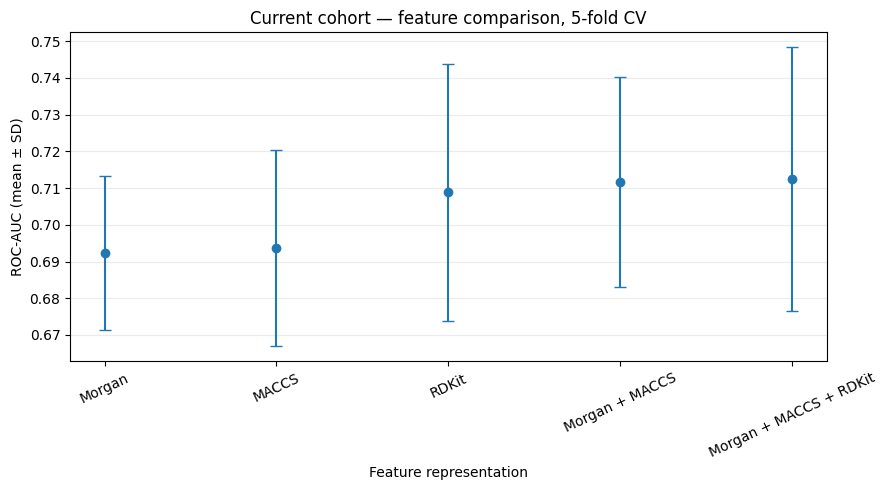

results\figures\feature_comparison_current_roc_auc.png


In [8]:
import matplotlib.pyplot as plt
def unused_path(path):
    if not path.exists(): return path
    for i in range(2,1000):
        p=path.with_name(f"{path.stem}_{i}{path.suffix}")
        if not p.exists(): return p
    raise FileExistsError(path)
FIGDIR=ROOT/"results/figures"; TABDIR=ROOT/"results/tables"; FIGDIR.mkdir(parents=True,exist_ok=True); TABDIR.mkdir(parents=True,exist_ok=True)
fig,ax=plt.subplots(figsize=(9,5)); ax.errorbar(feature_cv.name,feature_cv.roc_auc_mean,yerr=feature_cv.roc_auc_std,fmt="o",capsize=4)
ax.set(ylabel="ROC-AUC (mean ± SD)",xlabel="Feature representation",title="Current cohort — feature comparison, 5-fold CV"); ax.tick_params(axis="x",rotation=25); ax.grid(axis="y",alpha=.25); fig.tight_layout()
feature_fig=unused_path(FIGDIR/"feature_comparison_current_roc_auc.png"); fig.savefig(feature_fig,dpi=180,bbox_inches="tight"); plt.show(); print(feature_fig.relative_to(ROOT))

## 10–11. Algorithm comparison and results

Notebook 6-2 compares five fixed algorithms on Morgan + MACCS + RDKit (2,432 columns) using the same folds. Exact LightGBM and XGBoost parameters are retained from the audit and original code.

In [9]:
X_combined=feature_sets["Morgan + MACCS + RDKit"]; assert X_combined.shape==(1197,2432)
algorithm_cv=[]; algorithm_folds=[]; algorithm_oof=[]
for name,model in models.items():
    r,f,o=evaluate(name,model,X_combined); algorithm_cv.append(r); algorithm_folds+=f; algorithm_oof.append(o)
algorithm_cv=pd.DataFrame(algorithm_cv); algorithm_folds=pd.DataFrame(algorithm_folds); algorithm_oof=pd.DataFrame(algorithm_oof)
print("Fold-level scores"); display(algorithm_folds)
print("5-fold CV mean and population SD"); display(algorithm_cv)
print("Pooled OOF results"); display(algorithm_oof)
aa=audit.loc[audit.variant.eq("Notebook 6-2") & audit.analysis.eq("algorithm_comparison")]
algorithm_compare=compare_cv(algorithm_cv,aa); display(algorithm_compare)
aoof=[]
for _,r in algorithm_oof.iterrows():
    ref=aa.loc[aa.model.eq(r["name"])].iloc[0]
    for metric in ["accuracy","roc_auc","f1"]: aoof.append({"name":r["name"],"metric":metric,"recomputed_oof":r[metric],"audited_oof_reference":float(ref[f"oof_{metric}"]),"difference":float(r[metric])-float(ref[f"oof_{metric}"])})
algorithm_oof_compare=pd.DataFrame(aoof); print("Pooled OOF audit check"); display(algorithm_oof_compare)
algorithm_diff=algorithm_compare.loc[algorithm_compare.difference.abs()>TOL]; algorithm_oof_diff=algorithm_oof_compare.loc[algorithm_oof_compare.difference.abs()>TOL]
print("Algorithm CV/OOF deviations > tolerance:",len(algorithm_diff),len(algorithm_oof_diff),"; cause not established if any.")

Fold-level scores


,name,fold,accuracy,roc_auc,f1
0,Random Forest,1,0.704167,0.703387,0.782875
1,Random Forest,2,0.712500,0.761539,0.778135
2,Random Forest,3,0.635983,0.677388,0.720257
3,Random Forest,4,0.669456,0.673285,0.755418
4,Random Forest,5,0.719665,0.746747,0.783172
5,ExtraTrees,1,0.683333,0.671714,0.761006
6,ExtraTrees,2,0.720833,0.749762,0.788644
7,ExtraTrees,3,0.652720,0.702492,0.733119
8,ExtraTrees,4,0.677824,0.693988,0.752412
9,ExtraTrees,5,0.682008,0.742347,0.757962


5-fold CV mean and population SD


,name,n_samples,accuracy_mean,accuracy_std,roc_auc_mean,roc_auc_std,f1_mean,f1_std
0,Random Forest,1197,0.688354,0.031347,0.712469,0.035865,0.763971,0.024127
1,ExtraTrees,1197,0.683344,0.021797,0.712061,0.029613,0.758628,0.017868
2,HistGradientBoosting,1197,0.679191,0.023939,0.705011,0.032927,0.757430,0.015467
3,LightGBM,1197,0.660802,0.028719,0.702852,0.029891,0.726775,0.016650
4,XGBoost,1197,0.687538,0.024900,0.711764,0.025957,0.767474,0.017258


Pooled OOF results


,name,accuracy,roc_auc,f1
0,Random Forest,0.688388,0.711690,0.764073
1,ExtraTrees,0.683375,0.712319,0.758752
2,HistGradientBoosting,0.679198,0.703527,0.757269
3,LightGBM,0.660819,0.701165,0.726415
4,XGBoost,0.687552,0.710264,0.767413


,name,metric,recomputed,audited_current_reference,difference
0,Random Forest,accuracy,0.688354,0.688354,0.000000
1,Random Forest,roc_auc,0.712469,0.712469,0.000000
2,Random Forest,f1,0.763971,0.763971,0.000000
3,ExtraTrees,accuracy,0.683344,0.683344,0.000000
4,ExtraTrees,roc_auc,0.712061,0.712075,-0.000015
5,ExtraTrees,f1,0.758628,0.758628,0.000000
6,HistGradientBoosting,accuracy,0.679191,0.679191,0.000000
7,HistGradientBoosting,roc_auc,0.705011,0.705011,0.000000
8,HistGradientBoosting,f1,0.757430,0.757430,0.000000
9,LightGBM,accuracy,0.660802,0.660802,0.000000


Pooled OOF audit check


,name,metric,recomputed_oof,audited_oof_reference,difference
0,Random Forest,accuracy,0.688388,0.688388,0.000000
1,Random Forest,roc_auc,0.711690,0.711690,0.000000
2,Random Forest,f1,0.764073,0.764073,0.000000
3,ExtraTrees,accuracy,0.683375,0.683375,0.000000
4,ExtraTrees,roc_auc,0.712319,0.712313,0.000006
5,ExtraTrees,f1,0.758752,0.758752,0.000000
6,HistGradientBoosting,accuracy,0.679198,0.679198,0.000000
7,HistGradientBoosting,roc_auc,0.703527,0.703527,0.000000
8,HistGradientBoosting,f1,0.757269,0.757269,0.000000
9,LightGBM,accuracy,0.660819,0.660819,0.000000


Algorithm CV/OOF deviations > tolerance: 1 1 ; cause not established if any.


### Current-cohort algorithm ROC-AUC figure

Error bars show fold standard deviation; no historical values or final-winner label are included.

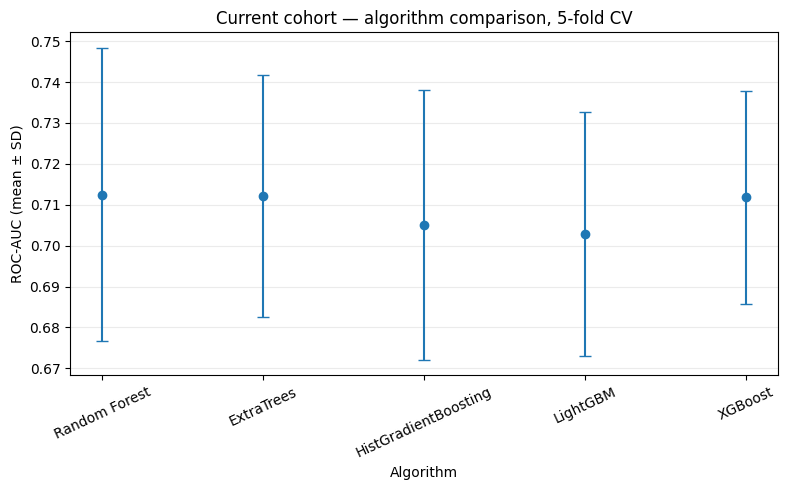

results\figures\algorithm_comparison_current_roc_auc.png


In [10]:
fig,ax=plt.subplots(figsize=(8,5)); ax.errorbar(algorithm_cv.name,algorithm_cv.roc_auc_mean,yerr=algorithm_cv.roc_auc_std,fmt="o",capsize=4)
ax.set(ylabel="ROC-AUC (mean ± SD)",xlabel="Algorithm",title="Current cohort — algorithm comparison, 5-fold CV"); ax.tick_params(axis="x",rotation=25); ax.grid(axis="y",alpha=.25); fig.tight_layout()
algorithm_fig=unused_path(FIGDIR/"algorithm_comparison_current_roc_auc.png"); fig.savefig(algorithm_fig,dpi=180,bbox_inches="tight"); plt.show(); print(algorithm_fig.relative_to(ROOT))

## 12. Historical Notebook 6 results — reference only

Historical metrics are reported separately from current reproduction. Historical 1,202-row source data are unavailable for row-level verification.

In [11]:
hist_feature=fa[["model","n_features","historical_accuracy_mean","historical_roc_auc_mean","historical_f1_mean"]].copy()
hist_algorithm=aa[["model","historical_accuracy_mean","historical_roc_auc_mean","historical_f1_mean"]].copy()
print("Historical Notebook 6-1 feature CV references (1,202 input / 1,201 valid rows):"); display(hist_feature)
print("Historical Notebook 6-2 algorithm CV references (1,202 input / 1,201 valid rows):"); display(hist_algorithm)

Historical Notebook 6-1 feature CV references (1,202 input / 1,201 valid rows):


,model,n_features,historical_accuracy_mean,historical_roc_auc_mean,historical_f1_mean
0,Morgan,2048,0.668610,0.692548,0.742664
1,MACCS,167,0.666957,0.697496,0.742802
2,RDKit,217,0.686940,0.715137,0.767225
3,Morgan + MACCS,2215,0.680277,0.712365,0.749497
4,Morgan + MACCS + RDKit,2432,0.686926,0.715225,0.764744


Historical Notebook 6-2 algorithm CV references (1,202 input / 1,201 valid rows):


,model,historical_accuracy_mean,historical_roc_auc_mean,historical_f1_mean
5,Random Forest,0.686926,0.715225,0.764744
6,ExtraTrees,0.688600,0.716535,0.765854
7,HistGradientBoosting,0.678624,0.705076,0.754381
8,LightGBM,0.676933,0.703336,0.738803
9,XGBoost,0.695263,0.712100,0.771736


## 13. Metric leadership (descriptive only)

Historical: ExtraTrees led ROC-AUC; XGBoost led Accuracy and F1. Current: Random Forest led Accuracy and ROC-AUC; XGBoost led F1. **Metric leadership within this comparative CV analysis does not establish the final model for the project.** The original notebooks selected and refit using these same CV results; this notebook does not select or refit a model.

In [12]:
leaders=pd.DataFrame([
 {"cohort":"Historical reference","Accuracy":hist_algorithm.loc[hist_algorithm.historical_accuracy_mean.idxmax(),"model"],"ROC-AUC":hist_algorithm.loc[hist_algorithm.historical_roc_auc_mean.idxmax(),"model"],"F1":hist_algorithm.loc[hist_algorithm.historical_f1_mean.idxmax(),"model"]},
 {"cohort":"Current reproduction","Accuracy":algorithm_cv.loc[algorithm_cv.accuracy_mean.idxmax(),"name"],"ROC-AUC":algorithm_cv.loc[algorithm_cv.roc_auc_mean.idxmax(),"name"],"F1":algorithm_cv.loc[algorithm_cv.f1_mean.idxmax(),"name"]}])
display(leaders)

,cohort,Accuracy,ROC-AUC,F1
0,Historical reference,XGBoost,ExtraTrees,XGBoost
1,Current reproduction,Random Forest,Random Forest,XGBoost


## 14. Methodological limitations

- These reproduce the audited legacy comparison workflow. Feature/model comparison and reporting use the same CV folds, so results may contain selection optimism and are not independent test performance.
- No nested CV and no independent test set.
- Features are constructed before CV. Descriptor coercion, infinity/extreme handling, and global all-NaN descriptor removal also occur before CV; these steps are unsupervised but not fold-local.
- Median imputation and VarianceThreshold are inside each pipeline and fitted within each training fold.
- The same stratified folds are used across representations and algorithms. Original selection on these same scores is not a final project model decision.
- Historical/current cohort differences are not row-level reconcilable; cause of score differences is not established from cohort sizes alone.
- No separate fold-local controlled reanalysis is performed here.

## 15. Reproducibility summary and outputs

Save current-cohort CV tables and two current-only CV ROC-AUC figures using non-overwriting filenames. Pooled OOF results are displayed separately and are not included in the CV-only tables.

In [13]:
feature_table=feature_cv.rename(columns={"name":"feature_set"})[["feature_set","accuracy_mean","accuracy_std","roc_auc_mean","roc_auc_std","f1_mean","f1_std"]]
algorithm_table=algorithm_cv.rename(columns={"name":"model"})[["model","accuracy_mean","accuracy_std","roc_auc_mean","roc_auc_std","f1_mean","f1_std"]]
feature_csv=unused_path(TABDIR/"feature_comparison_current.csv"); algorithm_csv=unused_path(TABDIR/"algorithm_comparison_current.csv")
feature_table.to_csv(feature_csv,index=False); algorithm_table.to_csv(algorithm_csv,index=False)
print("Saved",feature_csv.relative_to(ROOT),"and",algorithm_csv.relative_to(ROOT))
original61=next(ROOT.glob("6-1.*.ipynb")); original62=next(ROOT.glob("6-2.*.ipynb"))
protected={"DILIst_Final.csv":(DATA,"4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f68790a07a231b03dc32c7"),
 "Notebook 01":(ROOT/"notebooks/final/01_dataset_construction.ipynb","28b6c13409d1fc639ae17c6c0bca742a883cff29cc0de5acd3838d158f8da865"),
 "Notebook 02":(ROOT/"notebooks/final/02_morgan_fingerprint_analysis.ipynb","55e2ab69669f62f4bdab82e7d938c3b13e27e8948ed9a2028e06a5bb84971943"),
 "Notebook 03":(ROOT/"notebooks/final/03_rdkit_descriptor_modeling.ipynb","4752f555a27aaf4b3ac766c7baccc1d1fb9cbc9fc630b31ee1686a46ca6134db"),
 "Original 6-1":(original61,"f1aa473ed4bfb722c38aa55ffac5f3153fecf0cec06133057fb777b517601b78"),
 "Original 6-2":(original62,"7b62a9dd9a890cd61ecf8cc4eb86e87e11b40cda21202bd0bbecbd4a9cc1b789")}
checks=pd.DataFrame([{"file":n,"sha256":sha(p),"expected":h,"unchanged":sha(p)==h} for n,(p,h) in protected.items()]); display(checks)
assert checks.unchanged.all()
print("End-of-notebook hash checks passed. No tuning, final selection, model refit, or independent test was performed.")
print("Differences > tolerance — feature CV/OOF:",len(feature_diff),len(feature_oof_diff),"algorithm CV/OOF:",len(algorithm_diff),len(algorithm_oof_diff))

Saved results\tables\feature_comparison_current.csv and results\tables\algorithm_comparison_current.csv


,file,sha256,expected,unchanged
0,DILIst_Final.csv,4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f687...,4a3c37c704d02b6d0bb80e0727295ca8ba2fd988c4f687...,True
1,Notebook 01,28b6c13409d1fc639ae17c6c0bca742a883cff29cc0de5...,28b6c13409d1fc639ae17c6c0bca742a883cff29cc0de5...,True
2,Notebook 02,55e2ab69669f62f4bdab82e7d938c3b13e27e8948ed9a2...,55e2ab69669f62f4bdab82e7d938c3b13e27e8948ed9a2...,True
3,Notebook 03,4752f555a27aaf4b3ac766c7baccc1d1fb9cbc9fc630b3...,4752f555a27aaf4b3ac766c7baccc1d1fb9cbc9fc630b3...,True
4,Original 6-1,f1aa473ed4bfb722c38aa55ffac5f3153fecf0cec06133...,f1aa473ed4bfb722c38aa55ffac5f3153fecf0cec06133...,True
5,Original 6-2,7b62a9dd9a890cd61ecf8cc4eb86e87e11b40cda21202b...,7b62a9dd9a890cd61ecf8cc4eb86e87e11b40cda21202b...,True


End-of-notebook hash checks passed. No tuning, final selection, model refit, or independent test was performed.
Differences > tolerance — feature CV/OOF: 0 0 algorithm CV/OOF: 1 1
